<a href="https://colab.research.google.com/github/mranitabh/SELF-WORK/blob/main/CLASS2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

df = pd.read_csv("/content/mnist.csv")

print(df.shape)
print(df.head())
print(df.isnull().sum().sum())
print(df["class"].value_counts())

(4000, 786)
      id  class  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0  31953      5       0       0       0       0       0       0       0   
1  34452      8       0       0       0       0       0       0       0   
2  60897      5       0       0       0       0       0       0       0   
3  36953      0       0       0       0       0       0       0       0   
4   1981      3       0       0       0       0       0       0       0   

   pixel8  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0         0   

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["id", "class"])
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Perceptron(random_state=42))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', Perceptron(random_state=42))])

In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.84
              precision    recall  f1-score   support

           0       0.96      0.95      0.95        75
           1       0.87      0.92      0.89        97
           2       0.85      0.88      0.87        78
           3       0.78      0.81      0.80        84
           4       0.79      0.88      0.83        74
           5       0.78      0.82      0.80        73
           6       0.86      0.90      0.88        78
           7       0.82      0.87      0.85        85
           8       0.86      0.69      0.77        83
           9       0.82      0.67      0.74        73

    accuracy                           0.84       800
   macro avg       0.84      0.84      0.84       800
weighted avg       0.84      0.84      0.84       800

[[71  0  1  0  0  2  0  1  0  0]
 [ 0 89  1  2  0  0  0  0  5  0]
 [ 0  0 69  2  0  1  3  2  1  0]
 [ 1  1  3 68  0  5  2  3  1  0]
 [ 0  1  0  2 65  0  1  1  0  4]
 [ 2  3  0  3  0 60  2  1  1  1]
 [ 0  1  1  0  3  1 70  1  1

In [7]:
from sklearn.linear_model import LogisticRegression

#pipeline for Logistic Regression
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42, solver='liblinear', multi_class='ovr'))
])

# Trainonig the model
logistic_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(multi_class='ovr', random_state=42,
                                    solver='liblinear'))])

In [8]:
#  predictions with Logistic Regression
y_pred_logistic = logistic_pipeline.predict(X_test)

# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logistic))
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, y_pred_logistic))
print("\nLogistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logistic))

Logistic Regression Accuracy: 0.86

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        75
           1       0.90      0.97      0.94        97
           2       0.93      0.87      0.90        78
           3       0.84      0.86      0.85        84
           4       0.76      0.88      0.82        74
           5       0.79      0.75      0.77        73
           6       0.87      0.87      0.87        78
           7       0.86      0.87      0.87        85
           8       0.88      0.76      0.81        83
           9       0.79      0.77      0.78        73

    accuracy                           0.86       800
   macro avg       0.86      0.86      0.86       800
weighted avg       0.86      0.86      0.86       800


Logistic Regression Confusion Matrix:
 [[73  0  0  0  0  2  0  0  0  0]
 [ 0 94  0  2  0  0  0  0  1  0]
 [ 0  1 68  0  1  1  3  1  2  1]
 [ 1  1  2 72  0  1  2

/tmp/ipykernel_2518/1213043833.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis')


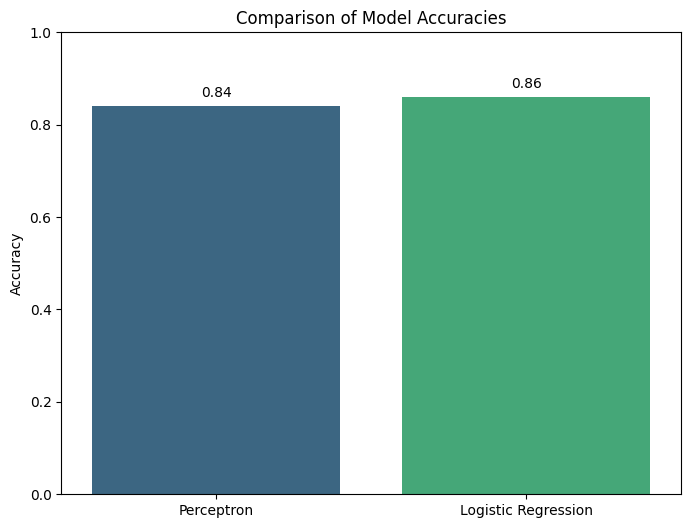

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

#  accuracies of both models
perceptron_accuracy = accuracy_score(y_test, y_pred)
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

models = ['Perceptron', 'Logistic Regression']
accuracies = [perceptron_accuracy, logistic_accuracy]

plt.figure(figsize=(8, 6))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title('Comparison of Model Accuracies')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy  between 0 and 1

for index, value in enumerate(accuracies):
    plt.text(index, value + 0.02, f'{value:.2f}', ha='center')

plt.show()

### Visualizing Sample Predictions

Let's visualize some images from the test set, along with their true labels and the predictions made by the Logistic Regression model.

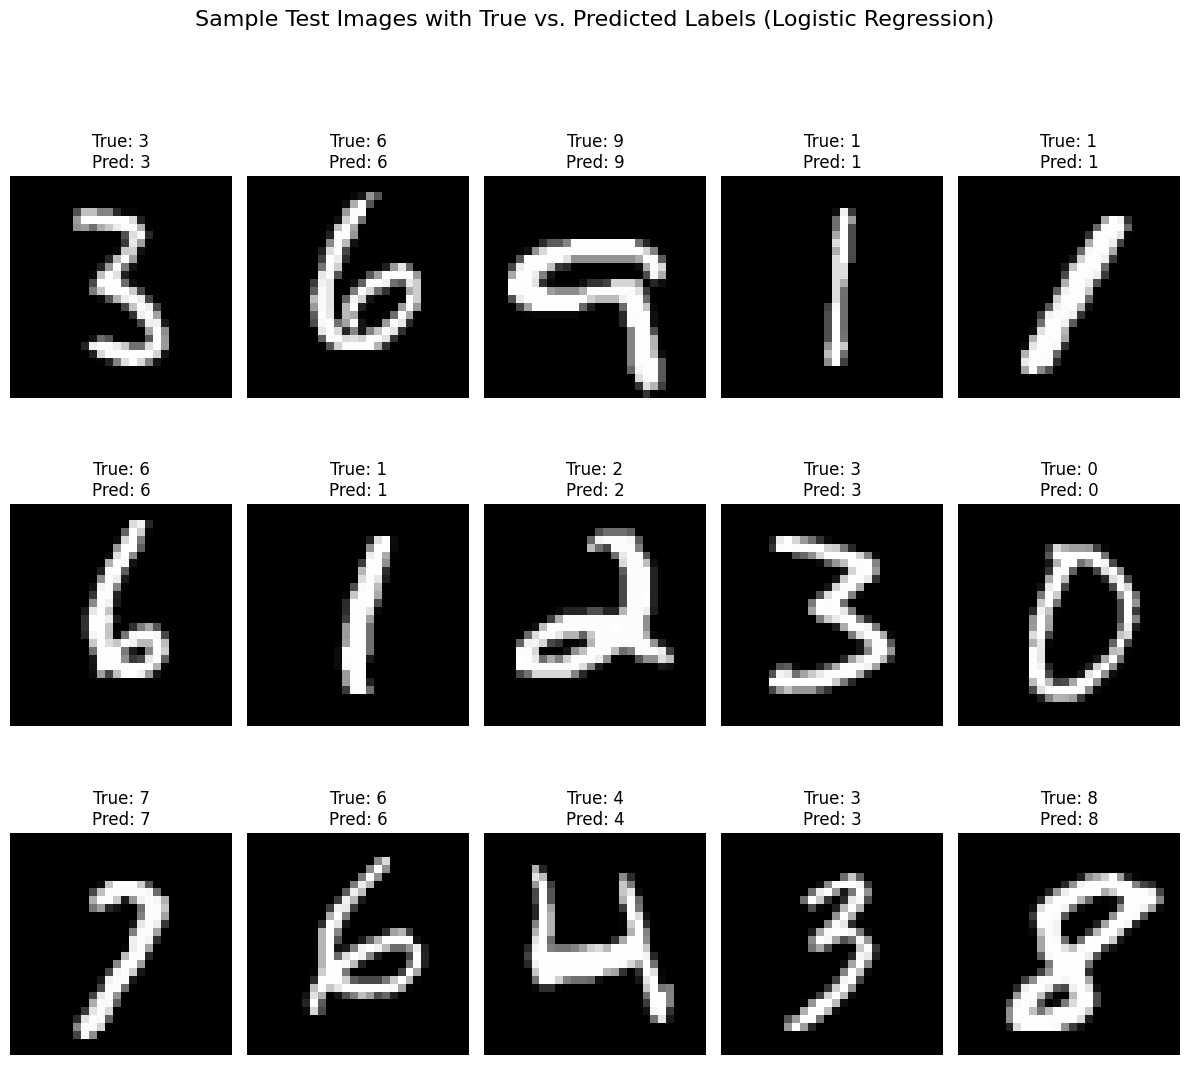

In [10]:
import numpy as np

# Reshaping the X_test data to image format (28x28 pixels)
X_test_images = X_test.values.reshape(-1, 28, 28)

plt.figure(figsize=(12, 12))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test_images[i], cmap='gray')
    plt.title(f"True: {y_test.iloc[i]}\nPred: {y_pred_logistic[i]}")
    plt.axis('off')
plt.suptitle('Sample Test Images with True vs. Predicted Labels (Logistic Regression)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

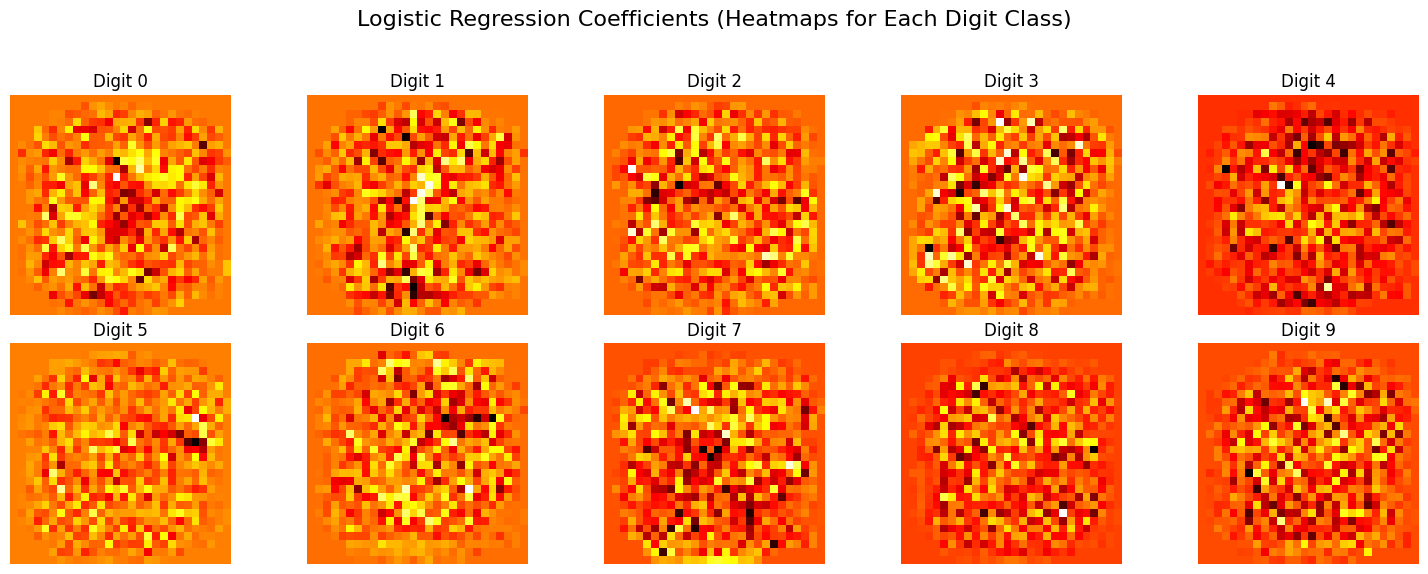

In [11]:
#  the coefficients from the Logistic Regression model

coefficients = logistic_pipeline.named_steps['model'].coef_

plt.figure(figsize=(15, 6))
for i in range(10): # Iterate over each digit class (0-9)
    plt.subplot(2, 5, i + 1)
    # coefficients for the current class into a 28x28 image
    coef_image = coefficients[i].reshape(28, 28)
    plt.imshow(coef_image, cmap='hot', interpolation='nearest')
    plt.title(f'Digit {i}')
    plt.axis('off')
plt.suptitle('Logistic Regression Coefficients (Heatmaps for Each Digit Class)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()